In [34]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy.ndimage import distance_transform_edt

In [35]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahmudulhasantasin/data-science-bowl-2018-competition-merged-mask")

print("Path to dataset files:", path)

DATASET_PATH = f"{path}/data science bowl 2018/stage1_train 2"

MAX_IMAGES = 10 #We only do the procedure for 10 images, in which we study the behaviour through visualisations. Since only studying over-segmentation is the task, we do not take the whole dataset.

Path to dataset files: /kaggle/input/datasets/mahmudulhasantasin/data-science-bowl-2018-competition-merged-mask


In [36]:
def watershed_no_mark(distance, merged_mask):
    #We calculate distance from foreground pixels to background, which makes distance maximum for center of nucleus.
    #This makes the nuclei peaks, but we need the flooding to happen from valleys, and hence, to make the nuclei valleys, we invert distance.
    labels = watershed(-distance, mask=merged_mask) #Inverted distance taken
    return labels

def watershed_mark(distance, merged_mask, min_distance):
    coords = peak_local_max(distance, min_distance=min_distance, labels=merged_mask) #Finds coordinates of the seed points, our nuclei which are peaks
    markers = np.zeros(distance.shape, dtype=int) #Creates blank image of the same size as that of original image
    for i, c in enumerate(coords):
        markers[c[0], c[1]] = i + 1 #Fills the markers image with the labels, identifying different seeds as different regions
    labels = watershed(-distance, markers, mask=merged_mask)
    return labels

Currently showing image 1
No. of nuclei in ground truth:  9
No. of nuclei detected through Naive Watershed:  1


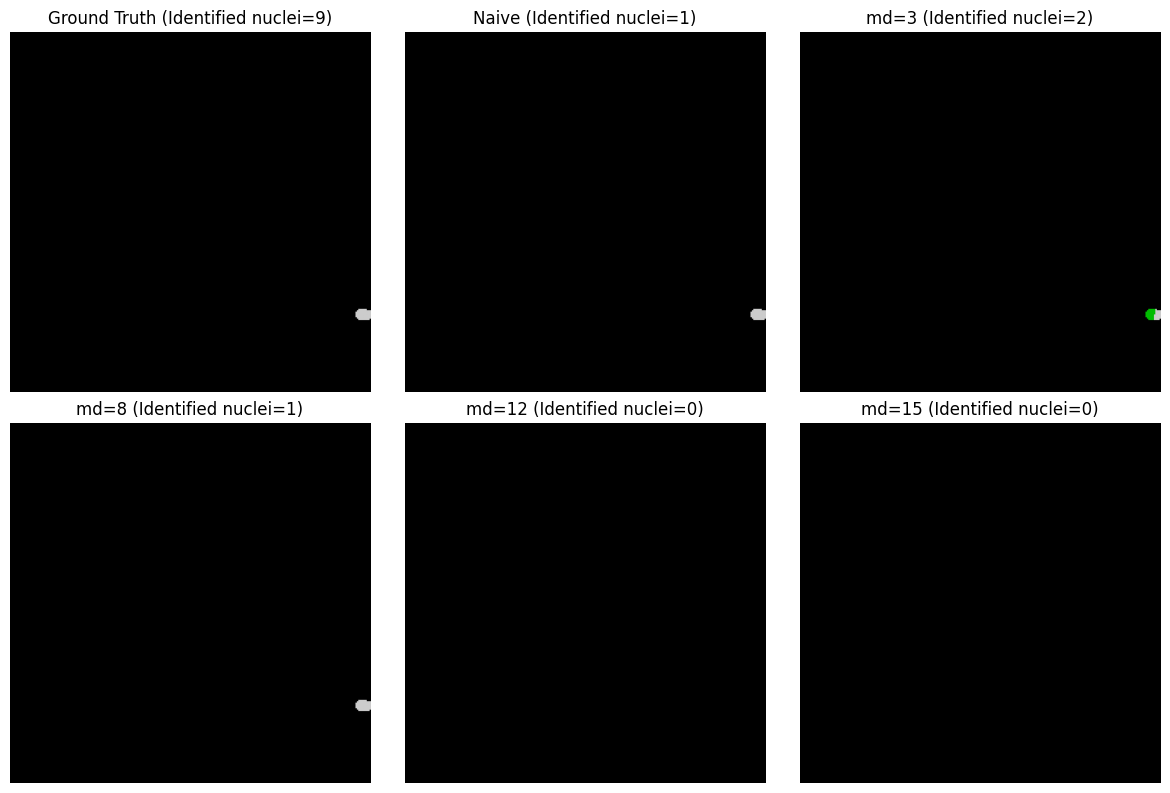


Currently showing image 2
No. of nuclei in ground truth:  23
No. of nuclei detected through Naive Watershed:  1


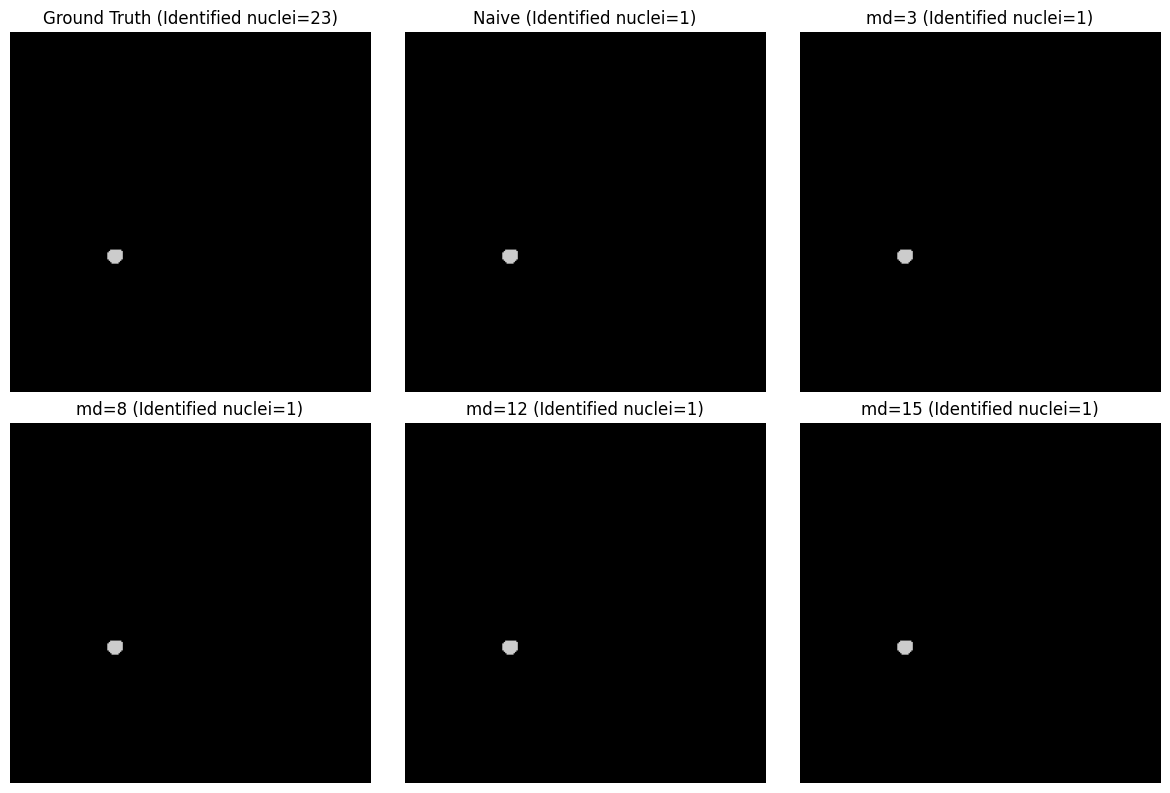


Currently showing image 3
No. of nuclei in ground truth:  9
No. of nuclei detected through Naive Watershed:  13


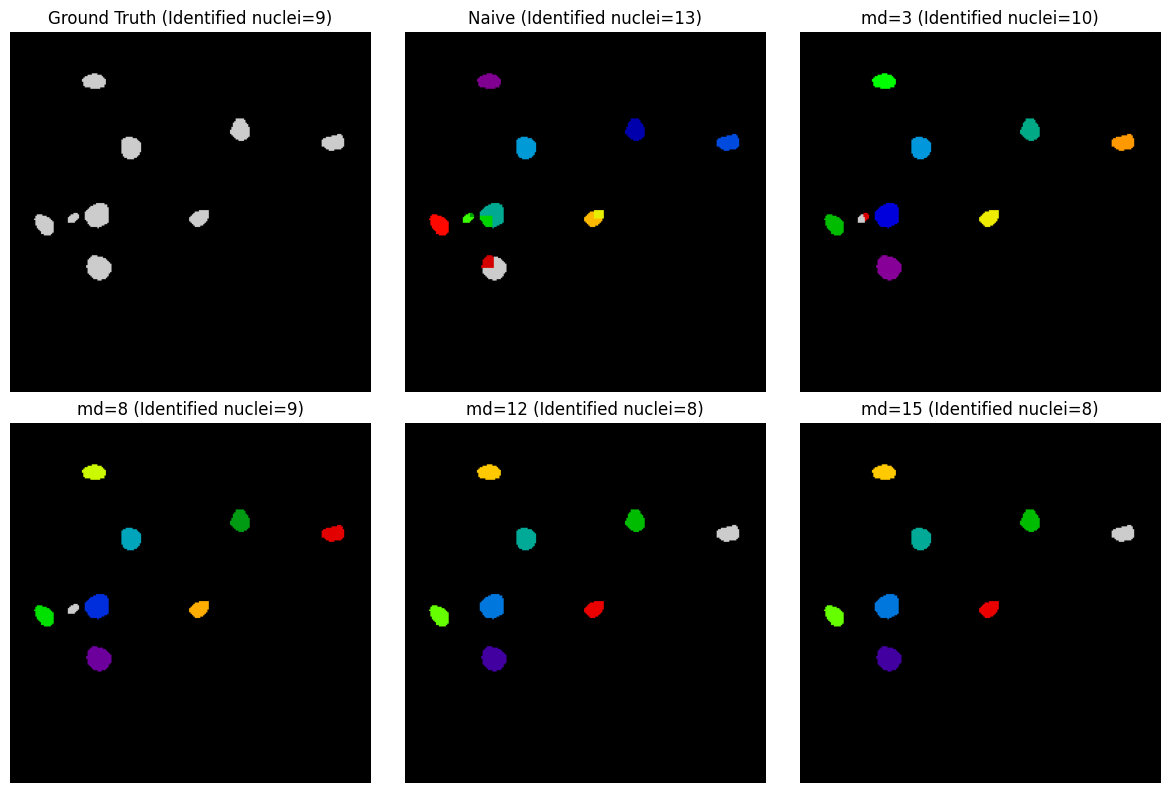


Currently showing image 4
No. of nuclei in ground truth:  4
No. of nuclei detected through Naive Watershed:  6


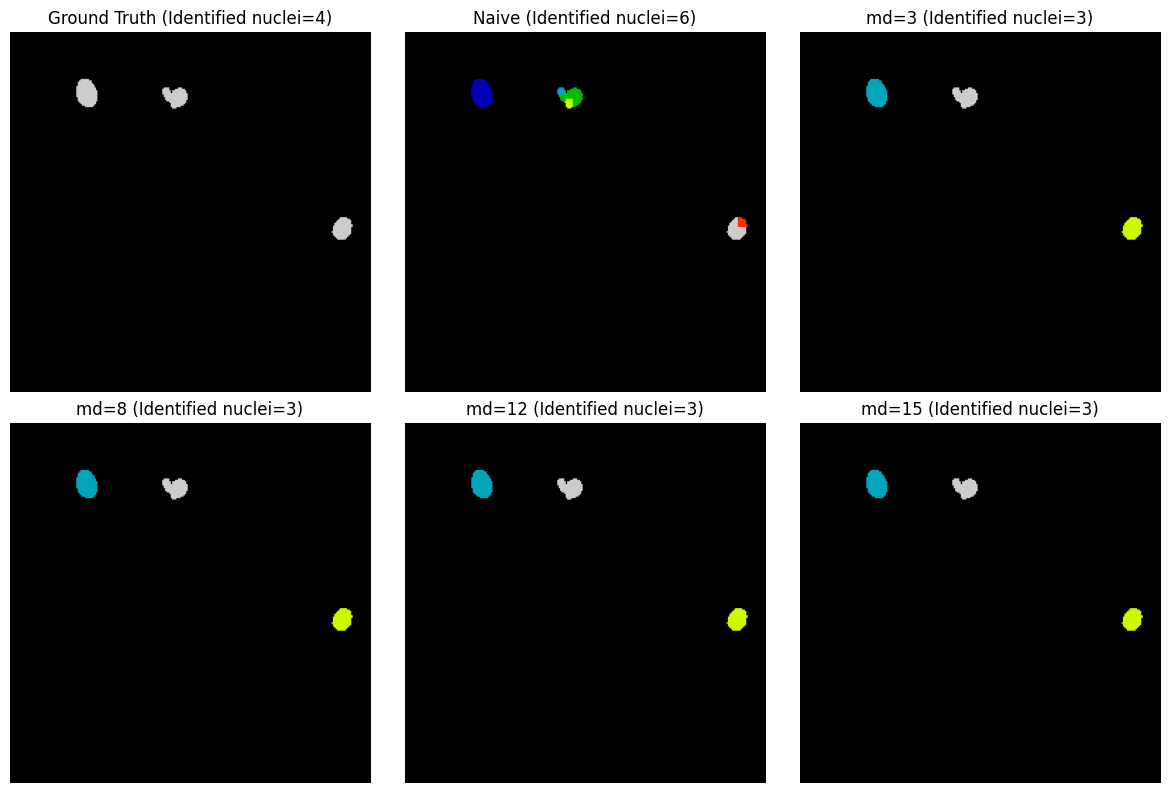


Currently showing image 5
No. of nuclei in ground truth:  12
No. of nuclei detected through Naive Watershed:  17


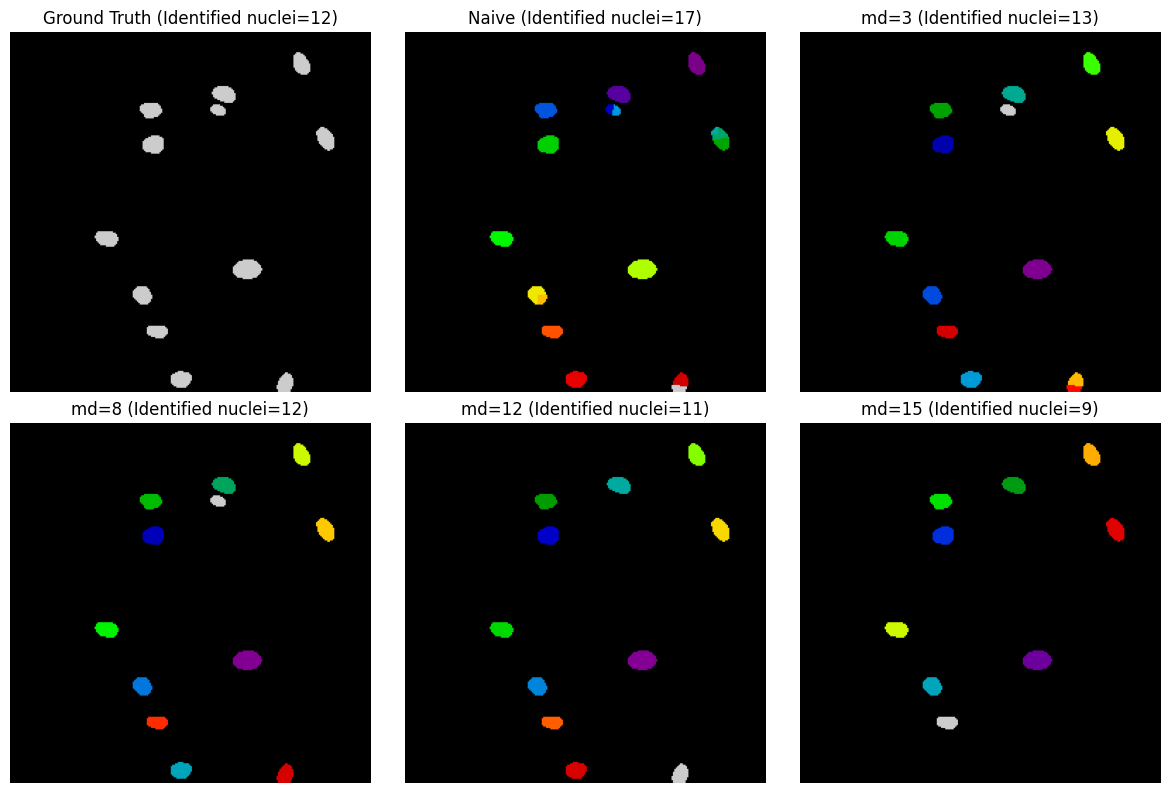


Currently showing image 6
No. of nuclei in ground truth:  20
No. of nuclei detected through Naive Watershed:  7


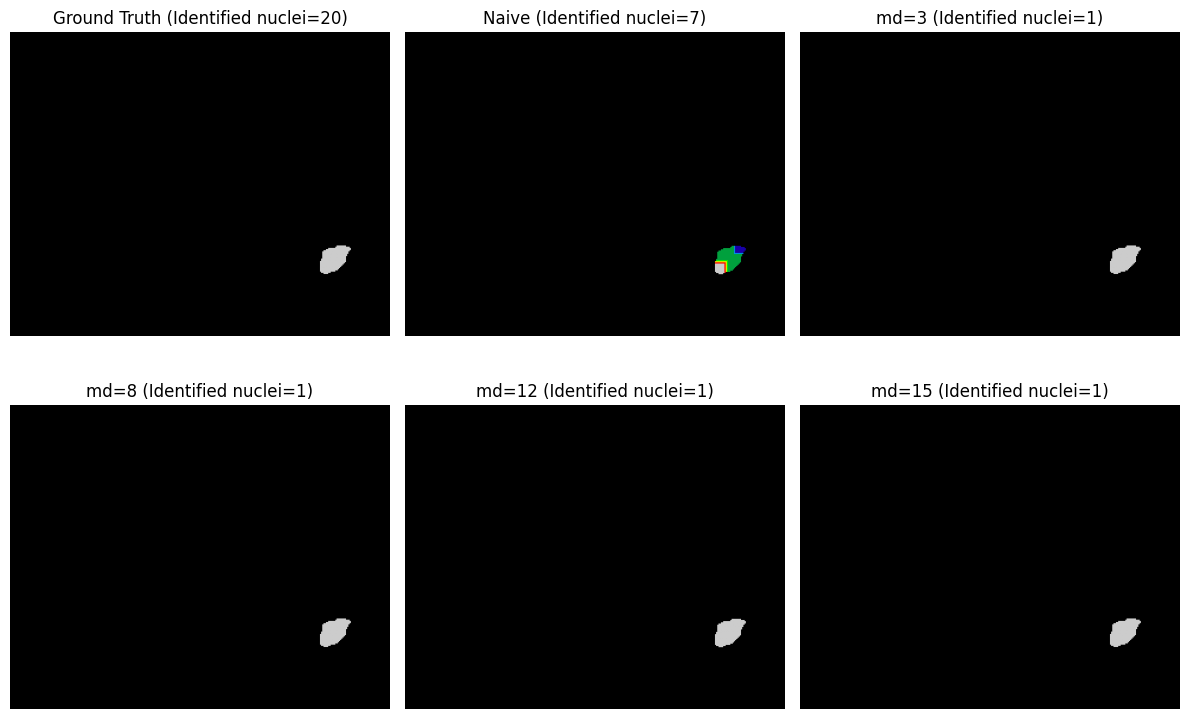


Currently showing image 7
No. of nuclei in ground truth:  37
No. of nuclei detected through Naive Watershed:  2


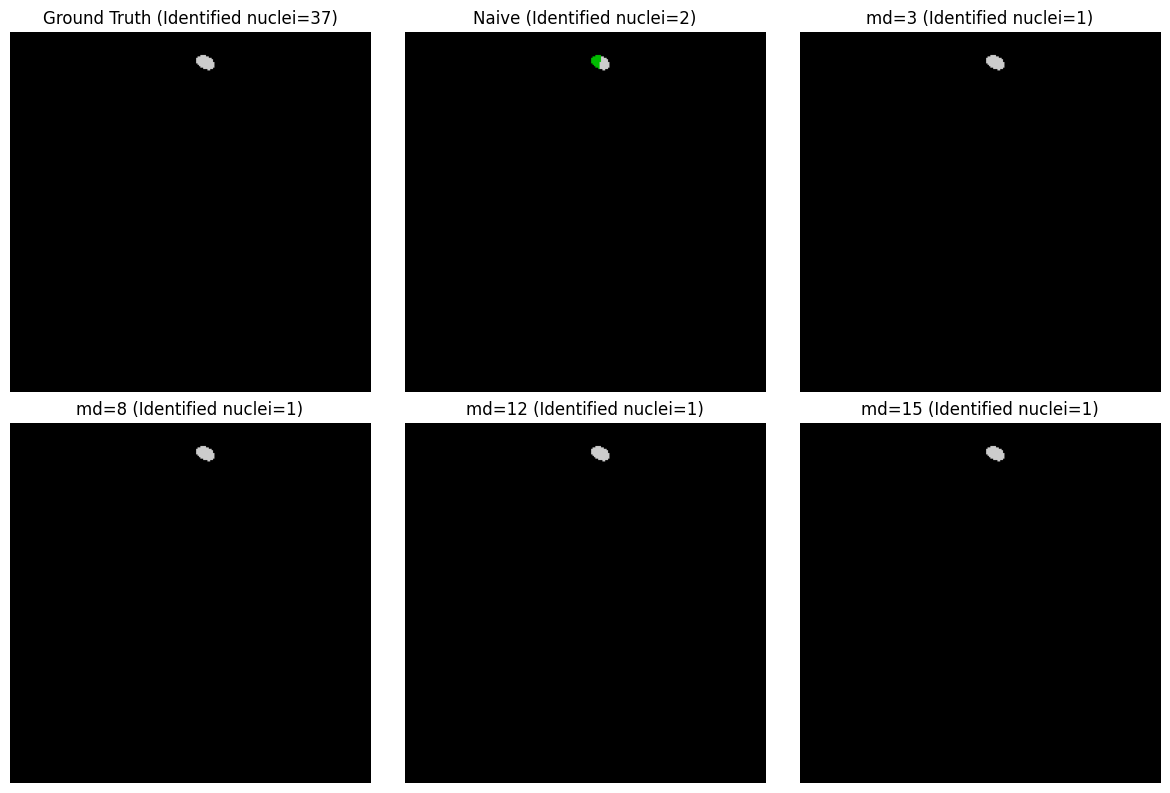


Currently showing image 8
No. of nuclei in ground truth:  83
No. of nuclei detected through Naive Watershed:  17


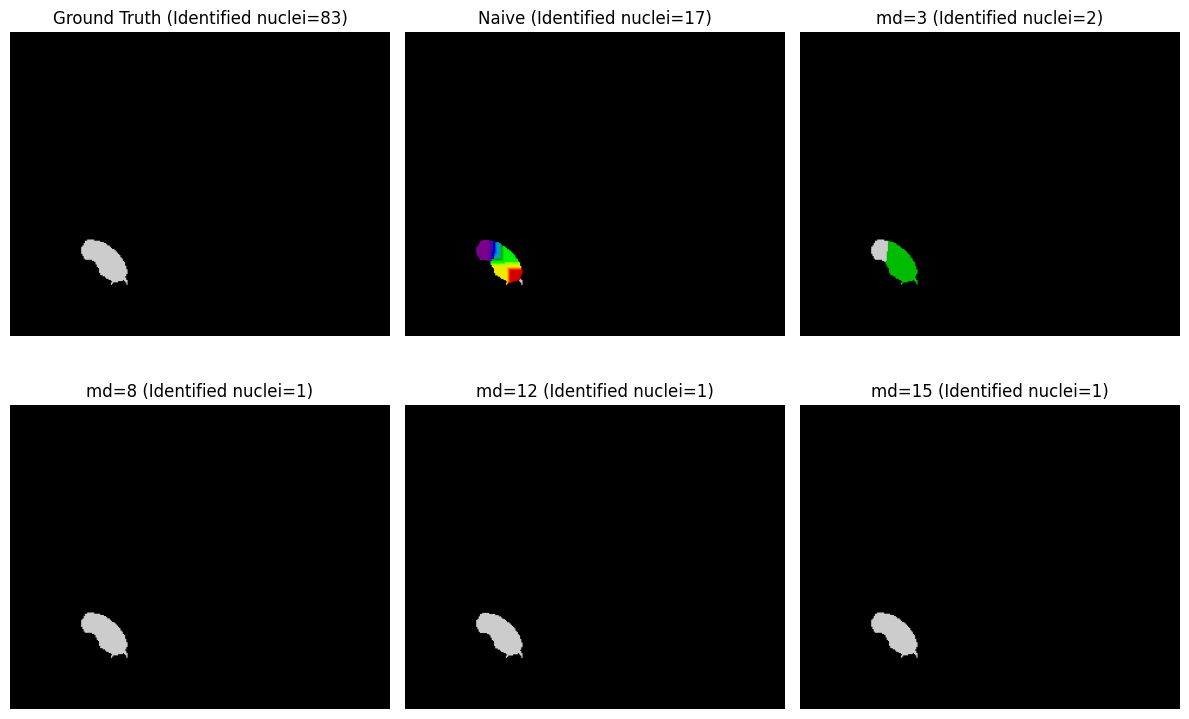


Currently showing image 9
No. of nuclei in ground truth:  20
No. of nuclei detected through Naive Watershed:  11


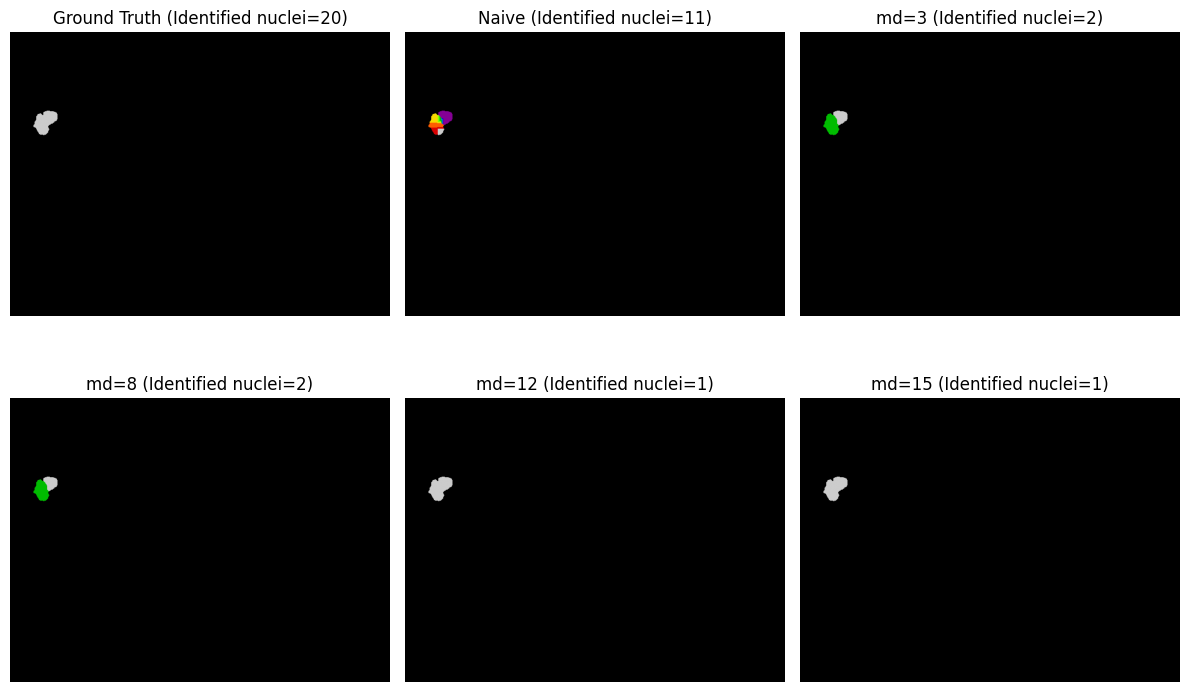


Currently showing image 10
No. of nuclei in ground truth:  2
No. of nuclei detected through Naive Watershed:  2


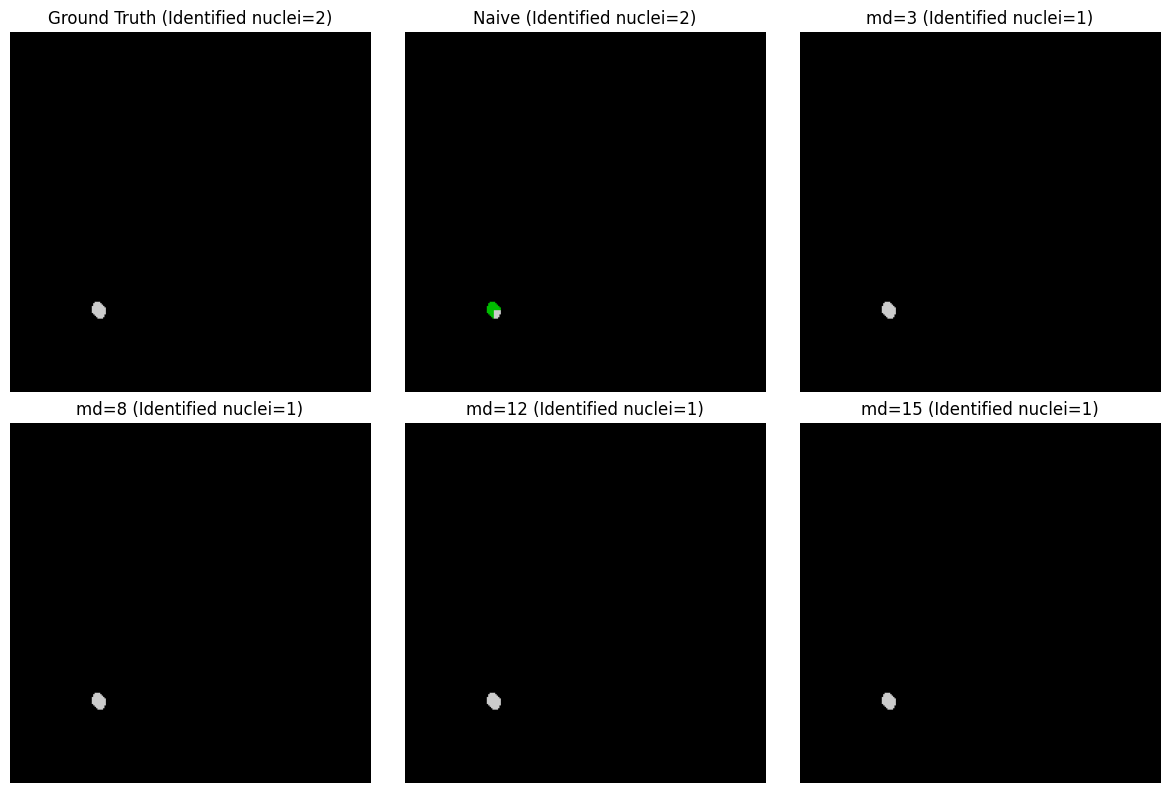

In [41]:
count = 0
for folder in os.listdir(DATASET_PATH):
    if count >= MAX_IMAGES:
        break
    
    sample_path = os.path.join(DATASET_PATH, folder)
    img_path = os.path.join(sample_path, "images")
    mask_path = os.path.join(sample_path, "masks")
    img_file = os.listdir(img_path)[0]
    gray = cv2.imread(os.path.join(img_path, img_file), 0) #We use it as a grayscale image

    mask_files = sorted(os.listdir(mask_path))
    merged = cv2.imread(os.path.join(mask_path, mask_files[0]), 0) #First image of masks directory contains the merged mask
    gt_count = len(mask_files)-1 #All other images in the masks directory, except the first one, represent one nucleus each
    merged = (merged>0).astype(np.uint8) #Converting mask into a binary image
    print(f"Currently showing image {count+1}")
    print("No. of nuclei in ground truth: ", gt_count)

    distance = distance_transform_edt(merged) #Checking distance from foreground pixel to nearest background pixel, to determine how deep the pixel is within the nucleus
    
    labels = watershed_no_mark(distance, merged)
    print("No. of nuclei detected through Naive Watershed: ", labels.max()) #Max since labels are assigned sequentially, and highest label gives us the total no. of nuclei

    markers = [3, 8, 12, 15] #Different distances allowed between two detected regions, i.e. nuclei
    results = {}
    for m in markers:
        results[m] = watershed_mark(distance, merged, min_distance=m)
    
    plt.figure(figsize=(12,8))

    plt.subplot(2,3,1)
    plt.title("Ground Truth (Identified nuclei=" + str(gt_count) + ")")
    plt.imshow(merged, cmap='nipy_spectral')
    plt.axis("off")
    
    plt.subplot(2,3,2)
    plt.title("Naive (Identified nuclei=" + str(labels.max()) + ")")
    plt.imshow(labels, cmap='nipy_spectral')
    plt.axis("off")

    plt.subplot(2,3,3)
    plt.title("md=3 (Identified nuclei=" + str(results[3].max()) + ")")
    plt.imshow(results[3], cmap='nipy_spectral')
    plt.axis("off")
    
    plt.subplot(2,3,4)
    plt.title("md=8 (Identified nuclei=" + str(results[8].max()) + ")")
    plt.imshow(results[8], cmap='nipy_spectral')
    plt.axis("off")
    
    plt.subplot(2,3,5)
    plt.title("md=12 (Identified nuclei=" + str(results[12].max()) + ")")
    plt.imshow(results[12], cmap='nipy_spectral')
    plt.axis("off")
    
    plt.subplot(2,3,6)
    plt.title("md=15 (Identified nuclei=" + str(results[15].max()) + ")")
    plt.imshow(results[15], cmap='nipy_spectral')
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

    count += 1
    print()

Naive watershed directly works on all local extrema in the distance-transformed image, which effectively treats every small variation as a separate region. As a result, it consistently produces a much higher number of nuclei than the ground truth, clearly showing severe over-segmentation.

For marker-controlled watershed, I experimented with four different minimum distance values between markers. Smaller values still led to some over-segmentation, but the results were better than the naive solution. Larger values performed worse in a different way, often merging nearby nuclei because markers were only placed when nuclei were sufficiently far apart. This behavior is intuitive, with lower distances allowing more splits, while higher distances encourage merging. Based on visual observation over the limited samples tested, a value of 8 for the minimum distance hyperparameter seemed to give the closest match to ground truth.

There were also a few cases where nuclei were overlapping more than they appeared visually, leading to unusually high ground truth counts. In such outliers, naive watershed definitely produced results closer to ground truth, but this was due to those samples being outliers, or unexpected readings into even minor variations, rather than meaningful separation. Overall, marker-controlled watershed provides a much more stable solution and clearly shows how marker placement helps control over-segmentation.